# City-Scale ETA Prediction & Routing Engine
### Spatiotemporal feature engineering + CatBoost for food delivery ETA

Instead of treating this as a flat regression over raw lat/lon and timestamps, this notebook models the delivery network as a spatiotemporal graph: restaurant/delivery points are quantized onto Uber's H3 hex grid, routes carry historical travel-time estimates, and time is encoded cyclically instead of linearly.

Dataset: [Food Delivery Dataset](https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset/) (Gaurav Malik, Kaggle).

## The Dataset

~45,000 delivery records across multiple cities.

| Category | Columns |
|---|---|
| Identifiers | `ID`, `Delivery_person_ID` |
| Demographics | `Delivery_person_Age`, `Delivery_person_Ratings` |
| Geospatial | `Restaurant_latitude/longitude`, `Delivery_location_latitude/longitude` |
| Temporal | `Order_Date`, `Time_Orderd`, `Time_Order_picked` |
| Environmental | `Weatherconditions`, `Road_traffic_density`, `City` |
| Operational | `Vehicle_condition`, `Type_of_order`, `Type_of_vehicle`, `multiple_deliveries`, `Festival` |
| Target | `Time_taken(min)` |

In [1]:
!pip install -q pandas numpy h3 scikit-learn catboost
!unzip -n -q archive.zip


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import time

import h3
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor


# Logging helper

def log_step(message, start_time=None):
    """Prints a timestamped progress message. Pass start_time to also print elapsed duration."""
    timestamp = time.strftime("%H:%M:%S", time.localtime())
    if start_time:
        duration = time.time() - start_time
        print(f"[{timestamp}] {message} (took {duration:.2f}s)")
    else:
        print(f"[{timestamp}] {message}")

## Prep time

`Time_taken` bundles driving time and restaurant wait time together. Separating them keeps the model from penalizing drivers for kitchen delays they don't control.

- `Prep_Time_min`: `Time_Order_picked` − `Time_Orderd`, with midnight-crossover correction and an upper clip to handle bad timestamps.

## Spatial features

Straight-line distance doesn't reflect how cars move through a city grid.

- `Edge_Distance_Manhattan_km`: L1-norm distance (with proper longitude scaling by `cos(lat)`), used as a closer approximation of city-grid driving than Haversine.
- `Effective_Distance`: Manhattan distance multiplied by a `Road_traffic_density` multiplier, as an interaction term for route friction.

### H3 hex grid

Raw `(lat, lon)` pairs are a problem for this kind of aggregation: each delivery has its own unique coordinates, so there's no way to group deliveries by "location" and compute something like average delivery time for a neighborhood — every row is its own island.

[H3](https://h3geo.org/) is a geospatial indexing system (originally built at Uber for ride/delivery dispatch) that solves this by tiling the earth's surface into a grid of hexagonal cells and giving each cell a unique ID string. Snapping a raw coordinate to its enclosing cell turns a continuous, effectively infinite coordinate space into a finite, reusable set of locations — many different deliveries that happen to land in the same neighborhood now map to the same cell ID, so they can be grouped and aggregated.

Hexagons are used instead of a simple lat/lon grid of squares because every hexagon has 6 neighboring cells at equal distance from its center. A square grid doesn't have that property — a diagonal neighbor is farther away than an edge neighbor — which distorts any distance or adjacency calculation done on the grid itself.

H3 also supports multiple resolutions (0 = coarsest, continent-sized cells, up to 15 = finest, sub-meter cells). This pipeline uses resolution 8, where each cell averages roughly 0.7 km² — small enough to distinguish neighborhoods within a city, large enough that the same cell gets reused across many orders.

Concretely, in `build_spatial_graph`:

- `Rest_H3` and `Del_H3` are the hex cell IDs for the restaurant and the drop-off point.
- `Spatial_Edge` (`Rest_H3 -> Del_H3`) represents a directed route between two neighborhoods.
- `Historical_Edge_Time` is the mean delivery time across all training orders that share that same edge — a learned prior for "how long a delivery from neighborhood A to neighborhood B usually takes," computed on train only to avoid leakage.
- If a specific edge never appears in training (a route between two neighborhoods with no historical orders), there's nothing to look up. A KNN regressor (k=5, distance-weighted) over the raw delivery coordinates fills in an estimate from the nearest edges that do have historical data.

## Time features

- `Hour_Sin` / `Hour_Cos`: cyclical encoding of order hour, so hour 23 and hour 0 are adjacent instead of maximally far apart.
- `Time_Bucket_168`: day-of-week × hour bucket (e.g. `Friday_19`) to capture weekly demand patterns like the Friday dinner rush.
- `Day_of_Week` is also passed on its own (in addition to `Time_Bucket_168`) so the model can learn coarser weekday effects even where a specific day-hour bucket is sparse.

## Driver profiling

- `Driver_Speed_Profile`: using train-only per-driver average delivery time, drivers below the 5th percentile or above the 95th are tagged `Fast_Outlier` / `Slow_Outlier`, otherwise `Normal`.
- `Delivery_person_Ratings` is also passed to the model directly as a numeric feature (in addition to the `Ratings_Category` quartile bucket used above). It's the single strongest raw correlate of delivery time in this dataset (r ≈ -0.34), and the quartile bucket alone throws away most of that signal.

In [3]:
# Distance functions

def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance between two points, in km."""
    r = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0) ** 2
    return r * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))


def manhattan_distance(lat1, lon1, lat2, lon2):
    """L1 (grid) distance between two points, in km."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = np.abs(lat2 - lat1)
    dlon = np.abs(lon2 - lon1)
    return r * (dlat + np.cos(lat1) * dlon)

In [4]:
# Data cleaning and feature engineering

def process_data(train_path, test_path):
    t0 = time.time()
    log_step("Reading raw CSV files...")

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    train_df['is_train'] = 1
    test_df['is_train'] = 0
    df = pd.concat([train_df, test_df], ignore_index=True)

    log_step("Cleaning strings and resolving missing values...")
    df_obj = df.select_dtypes(['object'])
    df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip()).replace('NaN', np.nan)

    if 'Time_taken(min)' in df.columns:
        df['Time_taken(min)'] = df['Time_taken(min)'].astype(str).str.extract(r'(\d+)').astype(float)

    for col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Vehicle_condition']:
        df[col] = df[col].astype(float)

    df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')

    log_step("Computing prep time...")
    # Time_Orderd/Time_Order_picked show up in the data as either HH:MM:SS or HH:MM
    t_order = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce').fillna(
        pd.to_datetime(df['Time_Orderd'], format='%H:%M', errors='coerce'))
    t_pick = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce').fillna(
        pd.to_datetime(df['Time_Order_picked'], format='%H:%M', errors='coerce'))

    df['Prep_Time_min'] = (t_pick - t_order).dt.total_seconds() / 60.0
    # Handle midnight crossovers (ordered at 23:55, picked up at 00:05)
    df['Prep_Time_min'] = np.where(df['Prep_Time_min'] < 0, df['Prep_Time_min'] + 1440, df['Prep_Time_min'])
    # Cap extreme outliers and fill missing with median
    df['Prep_Time_min'] = df['Prep_Time_min'].clip(upper=120)
    df['Prep_Time_min'] = df['Prep_Time_min'].fillna(df['Prep_Time_min'].median())

    log_step("Building cyclical time features and 168-hour buckets...")
    df['Hour'] = t_order.dt.hour.fillna(19.0)  # default to 19:00 if hour is missing
    df['Day_of_Week'] = df['Order_Date'].dt.dayofweek
    df['Time_Bucket_168'] = df['Day_of_Week'].astype(str) + "_" + df['Hour'].astype(str)
    df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24.0)
    df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24.0)

    log_step("Processing driver and vehicle fields...")
    df['Ratings_Category'] = pd.qcut(df['Delivery_person_Ratings'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    df['Ratings_Category'] = df['Ratings_Category'].cat.add_categories('Missing').fillna('Missing')
    df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
    df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0)
    df['Vehicle_condition'] = df['Vehicle_condition'].fillna(df['Vehicle_condition'].median())

    # Driver stats are computed on train rows only, to avoid leaking test data into the profile
    train_only = df[df['is_train'] == 1].copy()
    driver_stats = train_only.groupby('Delivery_person_ID')['Time_taken(min)'].mean()
    fast_drivers = driver_stats[driver_stats < driver_stats.quantile(0.05)].index
    slow_drivers = driver_stats[driver_stats > driver_stats.quantile(0.95)].index

    df['Driver_Speed_Profile'] = df['Delivery_person_ID'].apply(
        lambda x: 'Fast_Outlier' if x in fast_drivers else ('Slow_Outlier' if x in slow_drivers else 'Normal')
    )

    log_step("Data processing complete.", t0)
    return df

In [5]:
# Spatial graph construction (H3 grid + edge aggregation)

def build_spatial_graph(df, h3_resolution=8):
    t0 = time.time()
    log_step(f"Mapping coordinates to H3 cells (resolution {h3_resolution})...")

    # h3 v4 renamed geo_to_h3 to latlng_to_cell; support both so this runs on either version
    try:
        df['Rest_H3'] = df.apply(lambda r: h3.latlng_to_cell(r['Restaurant_latitude'], r['Restaurant_longitude'], h3_resolution), axis=1)
        df['Del_H3'] = df.apply(lambda r: h3.latlng_to_cell(r['Delivery_location_latitude'], r['Delivery_location_longitude'], h3_resolution), axis=1)
    except AttributeError:
        df['Rest_H3'] = df.apply(lambda r: h3.geo_to_h3(r['Restaurant_latitude'], r['Restaurant_longitude'], h3_resolution), axis=1)
        df['Del_H3'] = df.apply(lambda r: h3.geo_to_h3(r['Delivery_location_latitude'], r['Delivery_location_longitude'], h3_resolution), axis=1)

    # A directed edge between the restaurant's cell and the delivery's cell
    df['Spatial_Edge'] = df['Rest_H3'] + "->" + df['Del_H3']

    log_step("Computing Haversine and Manhattan distances...")
    df['Edge_Distance_km'] = haversine_distance(
        df['Restaurant_latitude'], df['Restaurant_longitude'],
        df['Delivery_location_latitude'], df['Delivery_location_longitude']
    )
    df['Edge_Distance_Manhattan_km'] = manhattan_distance(
        df['Restaurant_latitude'], df['Restaurant_longitude'],
        df['Delivery_location_latitude'], df['Delivery_location_longitude']
    )

    log_step("Computing distance x traffic interaction feature...")
    traffic_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Jam': 4}
    df['Traffic_Multiplier'] = df['Road_traffic_density'].map(traffic_map).fillna(2)
    df['Effective_Distance'] = df['Edge_Distance_Manhattan_km'] * df['Traffic_Multiplier']

    log_step("Computing historical average delivery time per edge...")
    train_mask = df['is_train'] == 1
    edge_stats = df[train_mask].groupby('Spatial_Edge')['Time_taken(min)'].mean().reset_index()
    edge_stats.columns = ['Spatial_Edge', 'Historical_Edge_Time']

    df = df.merge(edge_stats, on='Spatial_Edge', how='left')

    # Edges with no training history (cold starts) get imputed via KNN over raw coordinates
    unseen_mask = df['Historical_Edge_Time'].isna()
    if unseen_mask.sum() > 0:
        log_step(f"Imputing {unseen_mask.sum():,} cold-start edges via KNN...")
        knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
        known_df = df[~df['Historical_Edge_Time'].isna()]

        knn.fit(known_df[['Delivery_location_latitude', 'Delivery_location_longitude']],
                known_df['Historical_Edge_Time'])

        df.loc[unseen_mask, 'Historical_Edge_Time'] = knn.predict(
            df.loc[unseen_mask, ['Delivery_location_latitude', 'Delivery_location_longitude']]
        )

    log_step("Spatial graph complete.", t0)

    train = df[df['is_train'] == 1].copy()
    test = df[df['is_train'] == 0].copy()
    return train, test

## Model: CatBoost over XGBoost

1. Native categorical handling — the feature set is mostly categorical (weather, traffic, city, time bucket). CatBoost's ordered target encoding avoids the label-encoding step XGBoost would otherwise need.
2. Symmetric tree structure acts as regularization against noisy, one-off events in the data (e.g. flat tires, mispicks) that don't generalize.

In [6]:
# Model training and inference

def run_pipeline(train_path, test_path, output_path='submission.csv'):
    pipeline_start = time.time()

    df = process_data(train_path, test_path)
    train, test = build_spatial_graph(df, h3_resolution=8)

    num_features = [
        'Delivery_person_Age', 'Delivery_person_Ratings', 'Edge_Distance_km', 'Edge_Distance_Manhattan_km',
        'Effective_Distance', 'Historical_Edge_Time', 'Prep_Time_min',
        'Hour_Sin', 'Hour_Cos', 'Vehicle_condition', 'multiple_deliveries'
    ]

    cat_features = [
        'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle',
        'Festival', 'City', 'Ratings_Category', 'Driver_Speed_Profile', 'Time_Bucket_168', 'Day_of_Week'
    ]

    log_step("Preparing categorical columns for CatBoost...")
    for col in cat_features:
        train[col] = train[col].astype(str).replace('nan', 'Missing')
        test[col] = test[col].astype(str).replace('nan', 'Missing')

    X_train_full = train[num_features + cat_features]
    y_train_full = train['Time_taken(min)']
    X_test = test[num_features + cat_features]

    # Hold out a validation split for evaluation
    log_step("Creating 80/20 train-validation split...")
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42
    )

    log_step("Training CatBoost evaluation model...")
    t_val = time.time()

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.04,
        depth=8,
        l2_leaf_reg=3,
        loss_function='RMSE',
        eval_metric='R2',
        cat_features=cat_features,
        verbose=False,
        random_seed=42
    )

    model.fit(X_train_split, y_train_split,
              eval_set=(X_val, y_val),
              early_stopping_rounds=50)

    val_predictions = model.predict(X_val)

    mae = mean_absolute_error(y_val, val_predictions)
    mse = mean_squared_error(y_val, val_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, val_predictions)

    log_step("Validation scoring complete.", t_val)
    print("\n" + "=" * 50)
    print("VALIDATION METRICS:")
    print(f"   Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"   Mean Squared Error (MSE):      {mse:.4f}")
    print(f"   Root Mean Squared Error (RMSE):{rmse:.4f}")
    print(f"   R-squared (R2) Score:          {r2:.4f}")
    print("=" * 50 + "\n")

    # Retrain on the full training set for the final submission model
    log_step("Retraining on 100% of training data...")
    t_final = time.time()
    model.fit(X_train_full, y_train_full)
    log_step("Final model training complete.", t_final)

    # Generate predictions and write submission file
    log_step(f"Writing predictions to '{output_path}'...")
    test['Time_taken (min)'] = model.predict(X_test)

    submission = test[['ID', 'Time_taken (min)']]
    submission.to_csv(output_path, index=False)

    log_step(f"Pipeline complete. Wrote {len(submission):,} rows to '{output_path}'.", pipeline_start)
    return model

## Run the pipeline

`train.csv` and `test.csv` are unzipped from `archive.zip` in the setup cell above.

In [7]:
model = run_pipeline('train.csv', 'test.csv')

[13:14:12] Reading raw CSV files...
[13:14:13] Cleaning strings and resolving missing values...
[13:14:13] Computing prep time...
[13:14:13] Building cyclical time features and 168-hour buckets...
[13:14:13] Processing driver and vehicle fields...
[13:14:13] Data processing complete. (took 0.51s)
[13:14:13] Mapping coordinates to H3 cells (resolution 8)...
[13:14:14] Computing Haversine and Manhattan distances...
[13:14:14] Computing distance x traffic interaction feature...
[13:14:14] Computing historical average delivery time per edge...
[13:14:14] Imputing 112 cold-start edges via KNN...
[13:14:14] Spatial graph complete. (took 1.08s)
[13:14:14] Preparing categorical columns for CatBoost...
[13:14:14] Creating 80/20 train-validation split...
[13:14:14] Training CatBoost evaluation model...
[13:14:37] Validation scoring complete. (took 22.85s)

VALIDATION METRICS:
   Mean Absolute Error (MAE):     3.0383
   Mean Squared Error (MSE):      14.4236
   Root Mean Squared Error (RMSE):3.79

## Feature importance

Which engineered features the model actually leans on.

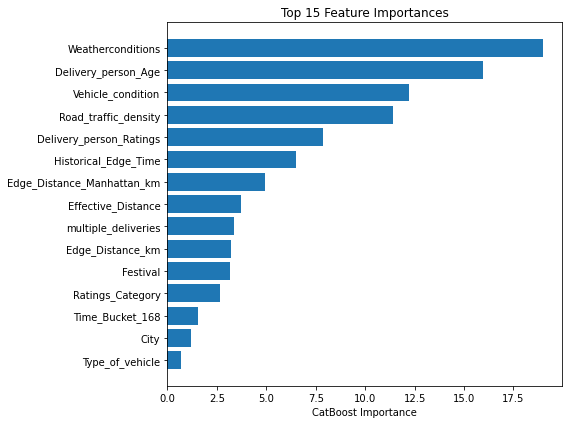

In [8]:
import matplotlib.pyplot as plt

importances = model.get_feature_importance(prettified=True)
plt.figure(figsize=(8, 6))
plt.barh(importances['Feature Id'][:15][::-1], importances['Importances'][:15][::-1])
plt.xlabel('CatBoost Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

## Results

Validation split (80/20), compared against a tuned XGBoost baseline on the same dataset:

| Metric | XGBoost | CatBoost + Network |
|---|---|---|
| MAE | 3.14 min | 3.04 min |
| RMSE | 3.93 min | 3.80 min |
| R² | 0.820 | 0.8355 |

## Future work (v2.0)

V1 predicts ETA for a fixed route and a fixed price. V2 extends this into a simulation: detect when conditions deviate from what the model expects, reroute and reprice around the disruption, and negotiate the final delivery fee between two agents instead of hard-coding it.

### 1. Anomaly detection

- Simulate a stream of incoming orders, then inject a localized disruption (e.g. a blocked route inside a specific H3 cell).
- For each order, compare the V1 model's predicted ETA against a simulated actual delivery time. Track the residual (`actual − predicted`).
- Maintain a rolling interquartile range (IQR) of residuals. If orders in the same H3 cell start showing residuals greater than 1.5× IQR, flag that cell as anomalous.

### 2. Rerouting and pricing

- Once a cell is flagged, recompute the route to avoid it — this increases `Edge_Distance_km` for orders passing through that area.
- Compute a base fare from a fixed formula, e.g. `$2.00 + $0.50 × distance + $0.10 × predicted time`.
- Apply a surge multiplier (1.5x–2.5x) on top of the base fare to set a maximum budget for that delivery, rather than charging the multiplier directly.

### 3. Negotiation between two agents

- Instead of the price being fixed at the surge-adjusted number, two LLM agents (LangGraph or CrewAI) negotiate the final price within that budget.
- Dispatcher agent (the platform): can check the surge budget through a tool, and opens with a low offer to protect margin.
- Driver agent (the worker): can evaluate route profitability through a tool (detour distance, traffic, offered price), and counters with a reasoned rejection if the offer doesn't cover the added distance/time.
- The two exchange offers and counter-offers until they agree or hit a negotiation ceiling. The final agreed price is logged along with the reasoning that produced it.

### 4. Measuring negotiating power

For every simulated negotiation, quantify which side held more leverage rather than describing it qualitatively:

- Let `dispatcher_offer` be the dispatcher's opening offer, `driver_ask` be the driver's opening ask, and `final_price` be the agreed price.
- `driver_concession = (driver_ask − final_price) / (driver_ask − dispatcher_offer)`
- `dispatcher_concession = (final_price − dispatcher_offer) / (driver_ask − dispatcher_offer)`
- Whichever side conceded less (the smaller ratio) held more leverage in that negotiation.
- Aggregate this ratio across many simulated disruptions, broken out by conditions (surge multiplier, reroute distance, anomaly severity), to see when leverage shifts from the platform to the driver and under what circumstances.